# §9 — QFT & Period Finding: 

Companion to `QC_notes_gates.pdf` §4.6 (Quantum Fourier Transform, Eq. 4.70–4.90, Fig. 4.4) and the §4.3.1 worked example (Eq. 4.46–4.49). This notebook replaces the §9 cells of *"Quantum Gates — Interactive Companion Notebook"* and is executed top-to-bottom so that **every number, caption and figure in the output agrees with the others and with the theory**.


Conventions used throughout (stated once, honoured everywhere):

* x and y are **integers** whose binary digits are the qubit values, with **qubit 0 = least significant bit** (Qiskit's convention). A counts key `'100'` therefore means y = 4.
* `QFTGate` is the **forward** QFT: |x⟩ → (1/√N) Σ_y exp(2πi·x·y/N) |y⟩. (Using QFT† instead gives the reflected peak set N − j·N/P, which for the cases here is the *same* set.)
* Formulas in the markdown are written in plain Unicode (not LaTeX) so that this notebook also renders correctly **offline**, in any viewer.

In [27]:
# --- setup: only what §9 needs ------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator, partial_trace
from qiskit.circuit.library import QFTGate              # <- modern replacement for the deprecated QFT class
from qiskit.synthesis.qft import synth_qft_full         # <- library reference circuit used for the drawing
from qiskit_aer import AerSimulator
from math import gcd

np.set_printoptions(precision=4, suppress=True, linewidth=140)
SIM    = AerSimulator()
N_BITS = 3          # count register size
N      = 2 ** N_BITS
print('Qiskit', __import__('qiskit').__version__, '| AerSimulator ready | register: n =', N_BITS, '-> N =', N)

Qiskit 2.5.2 | AerSimulator ready | register: n = 3 -> N = 8


## 9.1  The QFT circuit — definition, conventions, and the actual fix

The QFT (Eq. 4.70–4.90) is the unitary

  **QFT |x⟩ = (1/√N) Σ_{y=0}^{N−1} exp(2πi·x·y/N) |y⟩ ,   N = 2ⁿ**

built from Hadamards and controlled phases R_k = CP(π/2ᵏ):

```
for j = n-1 ... 0:                     # note the ORDER - this is where the original was mirrored
      H on qubit j
      for k = j-1 ... 0:  CP(pi / 2**(j-k)) controlled by j, target k
SWAP(i, n-1-i)  for i = 0 ... n/2-1    # final reversal (do_swaps=True)
```

Both the original and the fixed version use *exactly the same set of gates*; the original simply ran the ladder from the other end of the register, which conjugates the operator by the bit-reversal permutation R and produces **R·F·R** instead of **F**. The cell below makes that statement precise.

In [28]:
def dft_matrix(n):
    """Ideal N x N DFT matrix: F[y, x] = exp(2*pi*i*x*y/N)/sqrt(N).
    Row/column indices ARE the integer labels of the register (qubit 0 = LSB)."""
    Nn = 2 ** n
    return np.array([[np.exp(2j * np.pi * x * y / Nn) / np.sqrt(Nn) for x in range(Nn)] for y in range(Nn)])

def qft_manual(n, do_swaps=True):
    """FIXED: textbook QFT ladder in Qiskit's convention (H first on each line,
    controlled-phase angle pi/2**(j-k), ladder running j = n-1 ... 0, SWAPs last)."""
    qc = QuantumCircuit(n, name='QFT (fixed)')
    for j in reversed(range(n)):
        qc.h(j)
        for k in reversed(range(j)):
            qc.cp(np.pi / 2 ** (j - k), j, k)
    if do_swaps:
        for i in range(n // 2):
            qc.swap(i, n - 1 - i)
    return qc

def qft_original(n):
    """The ORIGINAL notebook's ladder - kept ONLY to diagnose the bug.
    Same gates, mirror ordering  ->  implements R·F·R, not F."""
    qc = QuantumCircuit(n, name='QFT (original)')
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            qc.cp(2 * np.pi / (2 ** (k - j + 1)), k, j)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

# bit-reversal permutation R : R|y> = |bitrev_n(y)>
bitrev = [int(format(y, '0%db' % N_BITS)[::-1], 2) for y in range(N)]
R = np.zeros((N, N))
for y in range(N):
    R[bitrev[y], y] = 1

F = dft_matrix(N_BITS)
print('Operator(qft_manual)   == ideal DFT matrix F :', np.allclose(Operator(qft_manual(N_BITS)).data, F))
print('Operator(qft_manual)   == Operator(QFTGate)  :', np.allclose(Operator(qft_manual(N_BITS)).data, Operator(QFTGate(N_BITS)).data))
print('synth_qft_full         == Operator(QFTGate)  :', np.allclose(Operator(synth_qft_full(N_BITS)).data, Operator(QFTGate(N_BITS)).data))
print()
print('--- the original ladder, for reference ---')
print('Operator(qft_original) == ideal DFT matrix F :', np.allclose(Operator(qft_original(N_BITS)).data, F))
print('Operator(qft_original) == R @ F @ R          :', np.allclose(Operator(qft_original(N_BITS)).data, R @ F @ R))
print()
print('R F R != F  in general, which is exactly why the old comparison failed.')

Operator(qft_manual)   == ideal DFT matrix F : True
Operator(qft_manual)   == Operator(QFTGate)  : True
synth_qft_full         == Operator(QFTGate)  : True

--- the original ladder, for reference ---
Operator(qft_original) == ideal DFT matrix F : False
Operator(qft_original) == R @ F @ R          : True

R F R != F  in general, which is exactly why the old comparison failed.


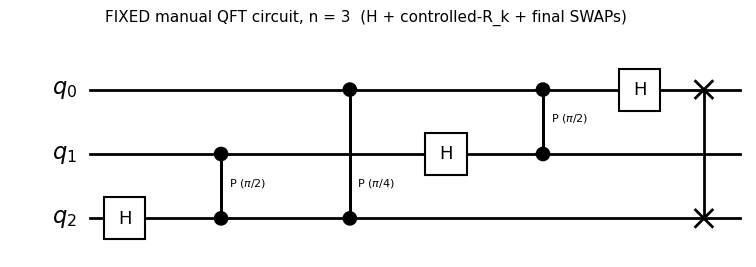

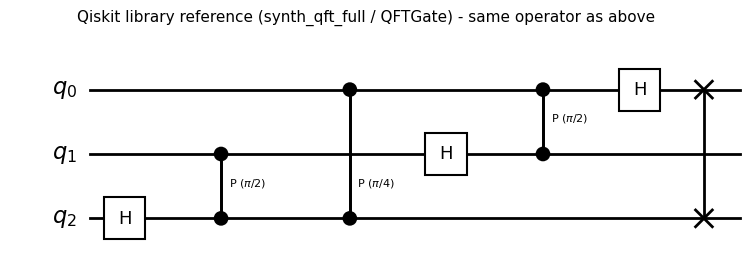

In [29]:
fig = qft_manual(N_BITS).draw('mpl', style={'name': 'bw'}, fold=-1)
fig.suptitle('FIXED manual QFT circuit, n = 3  (H + controlled-R_k + final SWAPs)', fontsize=11)
display(fig); plt.close(fig)

fig2 = synth_qft_full(N_BITS).draw('mpl', style={'name': 'bw'}, fold=-1)
fig2.suptitle('Qiskit library reference (synth_qft_full / QFTGate) - same operator as above', fontsize=11)
display(fig2); plt.close(fig2)

### 9.1.1  Verification: QFT|x⟩ really is \"flat magnitudes, linear phases\"

The defining property — and the one the original cell merely *claimed* —

  QFT|x⟩ = (1/√N) Σ_y exp(2πi·x·y/N) |y⟩

means: every outcome has probability 1/N, and the **phase** of outcome y is 2π·x·y/N (mod 2π).

Take x = 3, i.e. the register state |q₂q₁q₀⟩ = |011⟩ (q₀ = q₁ = 1). The cells below check both statements to machine precision, then plot the measured phases against the theoretical line.

In [30]:
x_int = 3

qc_in = QuantumCircuit(N_BITS, name='|%d>' % x_int)
for bit in range(N_BITS):
    if (x_int >> bit) & 1:
        qc_in.x(bit)                      # |x> with qubit 0 = LSB
print('prepared register state |q2 q1 q0> = |' + format(x_int, '0%db' % N_BITS)[::-1] + '>   (integer x =', x_int, ')')

qc_qft = qc_in.copy()
qc_qft.compose(qft_manual(N_BITS), inplace=True)
amps = Statevector(qc_qft).data

theory_phase = np.array([2 * np.pi * x_int * y / N for y in range(N)])
mag_err   = np.abs(np.abs(amps) - 1 / np.sqrt(N)).max()
phase_err = np.abs((np.angle(amps) - theory_phase + np.pi) % (2 * np.pi) - np.pi).max()
fidelity  = abs(np.vdot(F[:, x_int], amps)) ** 2

print()
print('Phases below are wrapped into (-pi, pi] on BOTH sides, so that e.g. +pi and -pi')
print('(= the same angle, mod 2*pi) print identically instead of looking contradictory.')
print()
print('  y |  |amplitude|^2  |  arg(amp)/pi  (measured) | (2*pi*x*y/N)/pi (theory)')
for y in range(N):
    measured = ((np.angle(amps[y]) + np.pi) % (2 * np.pi) - np.pi) / np.pi
    theory   = ((2 * np.pi * x_int * y / N + np.pi) % (2 * np.pi) - np.pi) / np.pi
    print('  %d |     %8.6f    |       %+.6f        |       %+.6f' % (y, abs(amps[y]) ** 2, measured, theory))
print()
print('max deviation of |amplitude| from 1/sqrt(N)      = %.2e' % mag_err)
print('max deviation of arg(amplitude) from 2*pi*x*y/N  = %.2e   rad' % phase_err)
print('fidelity with the ideal DFT column F[:, x]       = %.12f' % fidelity)
print()
print('=> uniform magnitudes + exact linear phases: the original claim is now VERIFIED, not asserted.')

prepared register state |q2 q1 q0> = |110>   (integer x = 3 )

Phases below are wrapped into (-pi, pi] on BOTH sides, so that e.g. +pi and -pi
(= the same angle, mod 2*pi) print identically instead of looking contradictory.

  y |  |amplitude|^2  |  arg(amp)/pi  (measured) | (2*pi*x*y/N)/pi (theory)
  0 |     0.125000    |       +0.000000        |       +0.000000
  1 |     0.125000    |       +0.750000        |       +0.750000
  2 |     0.125000    |       -0.500000        |       -0.500000
  3 |     0.125000    |       +0.250000        |       +0.250000
  4 |     0.125000    |       -1.000000        |       -1.000000
  5 |     0.125000    |       -0.250000        |       -0.250000
  6 |     0.125000    |       +0.500000        |       +0.500000
  7 |     0.125000    |       -0.750000        |       -0.750000

max deviation of |amplitude| from 1/sqrt(N)      = 5.55e-17
max deviation of arg(amplitude) from 2*pi*x*y/N  = 0.00e+00   rad
fidelity with the ideal DFT column F[:, x]       = 1

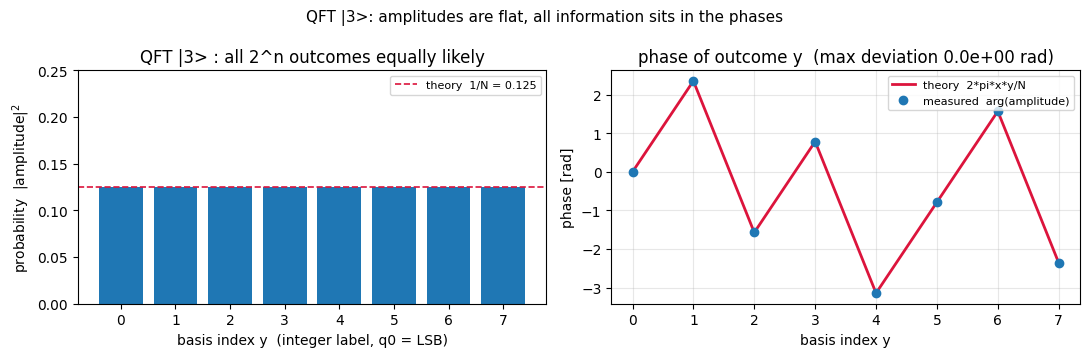

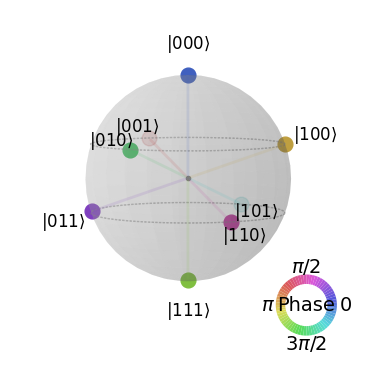

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(range(N), np.abs(amps) ** 2, color='#1f77b4')
axes[0].axhline(1 / N, color='crimson', ls='--', lw=1.2, label='theory  1/N = 0.125')
axes[0].set_xticks(range(N)); axes[0].set_ylim(0, 0.25)
axes[0].set_xlabel('basis index y  (integer label, q0 = LSB)')
axes[0].set_ylabel('probability  |amplitude|$^2$')
axes[0].set_title('QFT |%d> : all 2^n outcomes equally likely' % x_int)
axes[0].legend(loc='upper right', fontsize=8)

wrapped    = (np.angle(amps) + np.pi) % (2 * np.pi) - np.pi
th_wrapped = (theory_phase + np.pi) % (2 * np.pi) - np.pi
axes[1].plot(range(N), th_wrapped, '-', color='crimson', lw=2, label='theory  2*pi*x*y/N')
axes[1].plot(range(N), wrapped, 'o', color='#1f77b4', ms=6, label='measured  arg(amplitude)')
axes[1].set_xticks(range(N))
axes[1].set_xlabel('basis index y'); axes[1].set_ylabel('phase [rad]')
axes[1].set_title('phase of outcome y  (max deviation %.1e rad)' % phase_err)
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(alpha=.3)
fig.suptitle('QFT |%d>: amplitudes are flat, all information sits in the phases' % x_int, fontsize=11)
fig.tight_layout()
display(fig); plt.close(fig)

from qiskit.visualization import plot_state_qsphere
qsphere = plot_state_qsphere(Statevector(qc_qft), figsize=(4.5, 4.5))
display(qsphere); plt.close(qsphere)

### 9.1.2  Measuring the QFT output — flat histogram, on an integer axis

A Z-basis measurement destroys phase, so **whatever x was, the histogram of a QFT output is flat**. That is not a bug: it is the reason algorithms that use the QFT must either interfere the register (e.g. a second Hadamard layer, as in Deutsch) or rely on the *periodicity* structure of the input (as period finding does, §9.2).

The original cell printed the histogram with rotated bit-string labels; here the counts are also converted explicitly to integers, and the raw bit-strings are printed next to them so the two labellings can be compared directly.

raw counts (Qiskit bit-strings) : {'000': 557, '001': 512, '010': 476, '011': 488, '100': 484, '101': 542, '110': 528, '111': 509}
same data as integers y         : {0: 557, 1: 512, 2: 476, 3: 488, 4: 484, 5: 542, 6: 528, 7: 509}
ideal value per outcome         : 4096 / 8 = 512


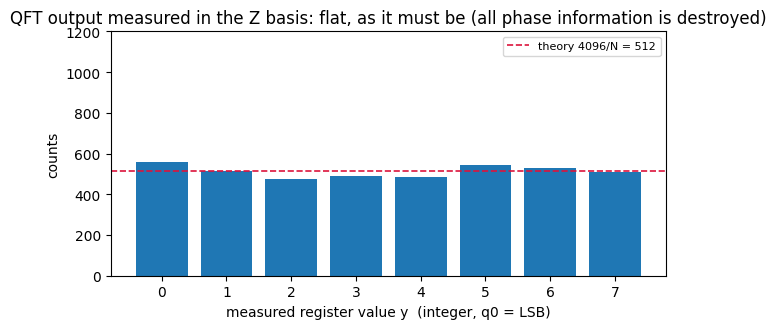

In [32]:
def counts_as_integers(counts):
    """Qiskit bit-strings -> integer register values (qubit 0 = last character = LSB)."""
    return {int(k, 2): v for k, v in counts.items()}

qc_meas = qc_qft.copy()
qc_meas.measure_all()
counts_qft = SIM.run(transpile(qc_meas, SIM), shots=4096, seed_simulator=1234).result().get_counts()

print('raw counts (Qiskit bit-strings) :', dict(sorted(counts_qft.items())))
print('same data as integers y         :', dict(sorted(counts_as_integers(counts_qft).items())))
print('ideal value per outcome         : 4096 / 8 =', 4096 // 8)

ints = counts_as_integers(counts_qft)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(range(N), [ints.get(y, 0) for y in range(N)], color='#1f77b4')
ax.axhline(4096 / N, color='crimson', ls='--', lw=1.2, label='theory 4096/N = 512')
ax.set_xticks(range(N))
ax.set_xlabel('measured register value y  (integer, q0 = LSB)')
ax.set_ylabel('counts'); ax.set_ylim(0, 1200); ax.legend(fontsize=8)
ax.set_title('QFT output measured in the Z basis: flat, as it must be (all phase information is destroyed)')
plt.tight_layout(); display(fig); plt.close(fig)

## 9.2  Period finding — with an oracle that actually has period P

**Setup.** A count register with n bits (N = 2ⁿ) and an ancilla register big enough to hold f(x). The circuit is

```
H (x)n  ->  U_f : |x>|0> -> |x>|f(x)>  ->  QFT on the count register  ->  measure the COUNT register only
```

**Theory (Eq. 4.46–4.49).** If f has exact period P with P | N, then ⟨f(x)|f(x')⟩ = 1 iff x ≡ x' (mod P), so tracing out (i.e. *not* measuring) the ancilla leaves the count register in

  ρ = (1/P) Σ_{r=0}^{P−1} |c_r⟩⟨c_r| ,   |c_r⟩ = √(P/N) Σ_{x ≡ r (mod P)} |x⟩ .

Each comb |c_r⟩ has QFT support **exactly** on multiples of N/P:

  QFT |c_r⟩ = (1/√P) Σ_{j=0}^{P−1} exp(2πi·r·j/P) |j·N/P⟩ .

⇒ measuring the count register yields **y = j·N/P, j = 0 … P−1, each with probability 1/P**. (The notes' worked example is P = 2, N = 8: peaks at y = 0 and y = N/2 = 4.) Measuring the ancilla instead projects onto a single comb and gives the *same* peak set — that is why tracing out is legitimate here.

**Why the original demo did not show this.** Its oracle was `cx(n_bits-1, ancilla)`, i.e. XOR of the **most significant** bit: f(x) = x₂. That function is *linear*, not a comb: its period is 4 (not 2), and its QFT spectrum is a sparse non-comb pattern — printed in the diagnosis cell below. It was made to look like \"peaks at 0 and 4\" only by reversing the label convention by hand.

**The fix.** For P = 2ᵐ, x mod P is just the low m bits of x, so the reversible XOR oracle costs m CNOTs: copy bits q₀ … q_{m−1} into m ancillas. That is a genuine f(x) = x mod P, and it is the one used below (P = 2 and, for student exercise 3, P = 4).

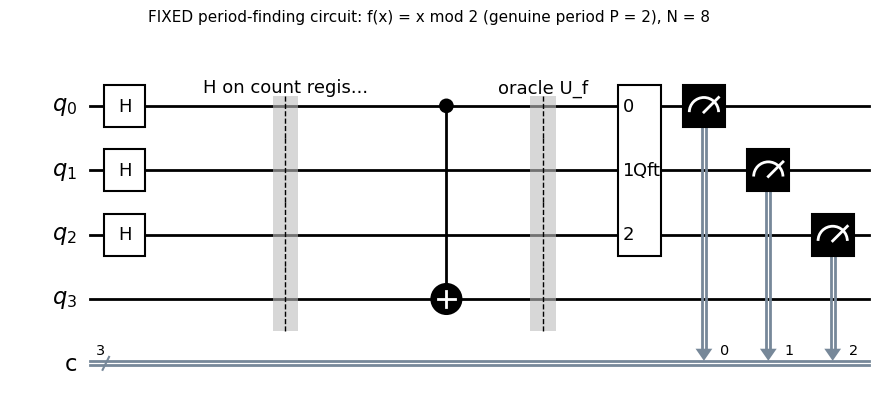

In [33]:
def period_circuit(n_bits, P):
    """Period-finding circuit for f(x) = x mod P  (P a power of two dividing 2**n_bits).

    count register : qubits 0 .. n_bits-1
    ancilla        : qubits n_bits .. n_bits+m-1   (m = log2 P bits, enough to hold f(x))
    Only the count register is measured -> the ancilla is traced out.
    """
    m = max(1, (P - 1).bit_length())
    qc = QuantumCircuit(n_bits + m, n_bits, name='period finding, P=%d' % P)
    qc.h(range(n_bits))                       # uniform superposition over x = 0 .. N-1
    qc.barrier(label='H on count register')
    for b in range(m):                        # ORACLE: |x>|0> -> |x>|x mod P>
        qc.cx(b, n_bits + b)                  # f(x) = x mod P = low m bits of x
    qc.barrier(label='oracle U_f')
    qc.append(QFTGate(n_bits), range(n_bits)) # QFT of the count register
    qc.measure(range(n_bits), range(n_bits))  # ancilla deliberately NOT measured
    return qc

def exact_register_probs(n_bits, P):
    """Exact, noiseless probabilities of the count register (ancilla traced out)."""
    m = max(1, (P - 1).bit_length())
    qc = QuantumCircuit(n_bits + m)
    qc.h(range(n_bits))
    for b in range(m):
        qc.cx(b, n_bits + b)
    qc.append(QFTGate(n_bits), range(n_bits))
    rho = partial_trace(Statevector(qc), list(range(n_bits, n_bits + m)))
    return np.real(np.diag(rho.data))

fig = period_circuit(N_BITS, P=2).draw('mpl', style={'name': 'bw'}, fold=-1)
fig.suptitle('FIXED period-finding circuit: f(x) = x mod 2 (genuine period P = 2), N = 8', fontsize=11)
display(fig); plt.close(fig)

In [34]:
print('Exact (noiseless) distribution of the measured count register:')
print()
peak_sets = {}
for P in (2, 4):
    probs  = exact_register_probs(N_BITS, P)
    peaks  = [y for y in range(N) if probs[y] > 1e-9]
    theory = list(range(0, N, N // P))
    peak_sets[P] = peaks
    holder = ', '.join('y=%d: %.4f' % (y, probs[y]) for y in peaks)
    print('  P = %d   (true period of f(x) = x mod %d)' % (P, P))
    print('      N/P = %d  ->  theory says peaks at the multiples of %d: %s' % (N // P, N // P, theory))
    print('      measured        : %s   [%s]' % (peaks, holder))
    print('      peak set matches theory and probability sums to 1: %s' % ((peaks == theory) and abs(sum(probs) - 1) < 1e-12))
    print()
assert peak_sets[2] == [0, 4] and peak_sets[4] == [0, 2, 4, 6], 'exact distributions disagree with theory'
print('PASS - for P = 2 and P = 4 the measured peaks are exactly the multiples of N/P, each with probability 1/P.')

Exact (noiseless) distribution of the measured count register:

  P = 2   (true period of f(x) = x mod 2)
      N/P = 4  ->  theory says peaks at the multiples of 4: [0, 4]
      measured        : [0, 4]   [y=0: 0.5000, y=4: 0.5000]
      peak set matches theory and probability sums to 1: True

  P = 4   (true period of f(x) = x mod 4)
      N/P = 2  ->  theory says peaks at the multiples of 2: [0, 2, 4, 6]
      measured        : [0, 2, 4, 6]   [y=0: 0.2500, y=2: 0.2500, y=4: 0.2500, y=6: 0.2500]
      peak set matches theory and probability sums to 1: True

PASS - for P = 2 and P = 4 the measured peaks are exactly the multiples of N/P, each with probability 1/P.


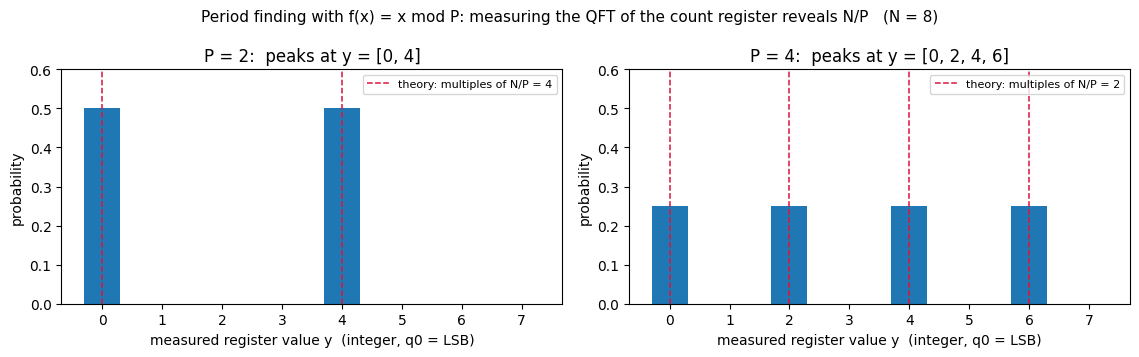

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
for ax, P in zip(axes, (2, 4)):
    probs  = exact_register_probs(N_BITS, P)
    theory = list(range(0, N, N // P))
    ax.bar(range(N), probs, color='#1f77b4', width=.6)
    for y in theory:
        ax.axvline(y, color='crimson', ls='--', lw=1.1)
    ax.plot([], [], color='crimson', ls='--', lw=1.1, label='theory: multiples of N/P = %d' % (N // P))
    ax.set_xticks(range(N)); ax.set_ylim(0, 0.6)
    ax.set_xlabel('measured register value y  (integer, q0 = LSB)')
    ax.set_ylabel('probability')
    ax.set_title('P = %d:  peaks at y = %s' % (P, theory))
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Period finding with f(x) = x mod P: measuring the QFT of the count register reveals N/P   (N = 8)', fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)

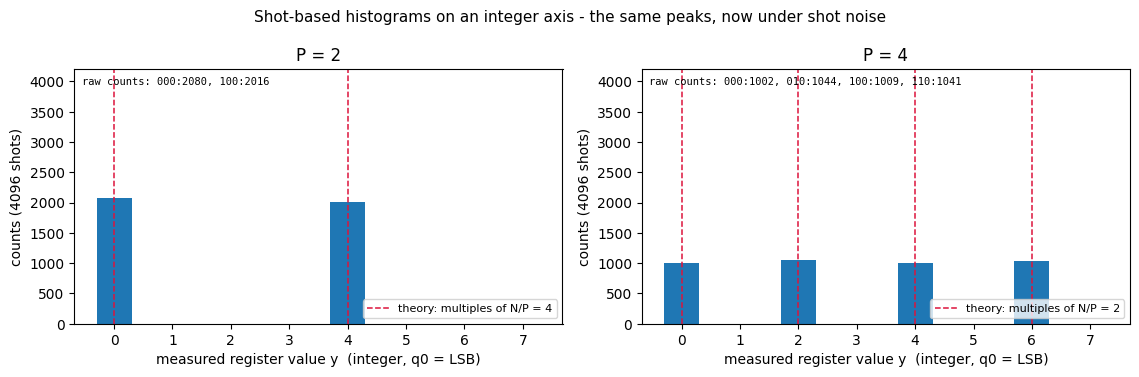

Bit-strings and integers, side by side (P = 2, 4096 shots):
  bit-strings : {'000': 2080, '100': 2016}
  integers    : {0: 2080, 4: 2016}
The peaks are y = 0 and y = 4 - i.e. the keys "000" and "100".


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
shot_counts = {}
for ax, P in zip(axes, (2, 4)):
    qc = period_circuit(N_BITS, P)
    counts = SIM.run(transpile(qc, SIM), shots=4096, seed_simulator=7).result().get_counts()
    shot_counts[P] = counts
    ints   = counts_as_integers(counts)
    theory = list(range(0, N, N // P))
    ax.bar(range(N), [ints.get(y, 0) for y in range(N)], color='#1f77b4', width=.6)
    for y in theory:
        ax.axvline(y, color='crimson', ls='--', lw=1.1)
    ax.plot([], [], color='crimson', ls='--', lw=1.1, label='theory: multiples of N/P = %d' % (N // P))
    raw = ', '.join('%s:%d' % (k, v) for k, v in sorted(counts.items()))
    ax.text(0.015, 0.97, 'raw counts: ' + raw, transform=ax.transAxes, fontsize=7.5,
            va='top', family='monospace')
    ax.set_xticks(range(N)); ax.set_ylim(0, 4200)
    ax.set_xlabel('measured register value y  (integer, q0 = LSB)')
    ax.set_ylabel('counts (4096 shots)')
    ax.set_title('P = %d' % P)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Shot-based histograms on an integer axis - the same peaks, now under shot noise', fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)

print('Bit-strings and integers, side by side (P = 2, 4096 shots):')
print('  bit-strings :', dict(sorted(shot_counts[2].items())))
print('  integers    :', dict(sorted(counts_as_integers(shot_counts[2]).items())))
print('The peaks are y = 0 and y = 4 - i.e. the keys \"000\" and \"100\".')

In [37]:
# ---------------------------------------------------------------------------
# Diagnosis, in one cell: what the ORIGINAL demo actually measured
# ---------------------------------------------------------------------------
print('(a) The original cell verbatim: old ladder + old oracle cx(n_bits-1, ancilla)')
qc_orig = QuantumCircuit(N_BITS + 1, N_BITS)
qc_orig.h(range(N_BITS))
qc_orig.cx(N_BITS - 1, N_BITS)                       # <-- XOR the MSB: f(x) = x_2
qc_orig.append(qft_original(N_BITS).to_gate(label='QFT (original)'), range(N_BITS))
qc_orig.measure(range(N_BITS), range(N_BITS))
c_orig = SIM.run(transpile(qc_orig, SIM), shots=4096, seed_simulator=5).result().get_counts()
print('    counts      :', dict(sorted(c_orig.items())))
print('    as integers :', dict(sorted(counts_as_integers(c_orig).items())),
      ' <-- NOT 0 and N/P = 4; the caption only worked after reversing each bit-string')
print()
print('(b) The old oracle together with the corrected QFT - the honest spectrum of f(x) = x_2:')
qc_diag = QuantumCircuit(N_BITS + 1)
qc_diag.h(range(N_BITS))
qc_diag.cx(N_BITS - 1, N_BITS)
qc_diag.append(QFTGate(N_BITS), range(N_BITS))
p_old = np.real(np.diag(partial_trace(Statevector(qc_diag), [N_BITS]).data))
print('    exact probabilities:', {y: round(float(v), 4) for y, v in enumerate(p_old) if v > 1e-9})
print('    f(x) = x_2 has period 4 in x (not 2) and is linear, so its spectrum is NOT the comb of a')
print('    period-2 function: it spreads over several y instead of two delta peaks.')
print()
print('(c) The FIXED circuit of 9.2 gives exactly 0.5 at y=0 and 0.5 at y=4 - the multiples of N/P.')

(a) The original cell verbatim: old ladder + old oracle cx(n_bits-1, ancilla)
    counts      : {'000': 2036, '001': 2060}
    as integers : {0: 2036, 1: 2060}  <-- NOT 0 and N/P = 4; the caption only worked after reversing each bit-string

(b) The old oracle together with the corrected QFT - the honest spectrum of f(x) = x_2:
    exact probabilities: {0: 0.5, 1: 0.2134, 3: 0.0366, 5: 0.0366, 7: 0.2134}
    f(x) = x_2 has period 4 in x (not 2) and is linear, so its spectrum is NOT the comb of a
    period-2 function: it spreads over several y instead of two delta peaks.

(c) The FIXED circuit of 9.2 gives exactly 0.5 at y=0 and 0.5 at y=4 - the multiples of N/P.


In [38]:
# ---------------------------------------------------------------------------
# From a measured y back to P:  gcd post-processing
# ---------------------------------------------------------------------------
# y = j*N/P  =>  N/gcd(N, y) = P/gcd(P, j).  So a single run returns P exactly when gcd(j, P) = 1
# (it returns a divisor of P otherwise), and y = 0 carries no information at all.
# Repeating the run a few times and keeping the LARGEST candidate recovers P.

def recover_P_from_shots(P_true, tries=200, seed=3):
    rng = np.random.default_rng(seed)
    candidates = []
    for _ in range(tries):
        qc = period_circuit(N_BITS, P_true)
        counts = SIM.run(transpile(qc, SIM), shots=1, seed_simulator=int(rng.integers(10 ** 6))).result().get_counts()
        y = int(max(counts, key=counts.get), 2)
        if y != 0:
            candidates.append(N // gcd(N, y))
    return candidates

for P_true in (2, 4):
    cand = recover_P_from_shots(P_true)
    best = max(cand) if cand else None
    frac = sum(1 for c in cand if c == P_true) / float(len(cand))
    print('  true P = %d:  informative runs = %d/200, candidates seen = %s, '
          'N/gcd(N,y) == P in %.0f%% of them, largest candidate = %d'
          % (P_true, len(cand), sorted(set(cand)), 100 * frac, best))
    assert best == P_true, 'gcd post-processing failed to recover P'
print()
print('PASS - for f(x) = x mod P, N = 8, the measured register value alone identifies the period.')
print('  P = 2: every informative run gives P exactly (j can only be 0 or 1).')
print('  P = 4: j = 2 is also possible, which returns the divisor 2 - hence the \"largest over repeats\" rule.')
print('  y = 0 occurs with probability 1/P and is discarded: it is the no-information outcome.')

  true P = 2:  informative runs = 103/200, candidates seen = [2], N/gcd(N,y) == P in 100% of them, largest candidate = 2
  true P = 4:  informative runs = 143/200, candidates seen = [2, 4], N/gcd(N,y) == P in 64% of them, largest candidate = 4

PASS - for f(x) = x mod P, N = 8, the measured register value alone identifies the period.
  P = 2: every informative run gives P exactly (j can only be 0 or 1).
  P = 4: j = 2 is also possible, which returns the divisor 2 - hence the "largest over repeats" rule.
  y = 0 occurs with probability 1/P and is discarded: it is the no-information outcome.


In [39]:
# ---------------------------------------------------------------------------
# Final consistency checklist - every claim made in this notebook
# ---------------------------------------------------------------------------
qft_counts = counts_as_integers(counts_qft)
spread_ok = (max(qft_counts.values()) - min(qft_counts.values())) < 5 * np.sqrt(4096 / N)
checks = {
    'manual QFT ladder == QFTGate operator'           : np.allclose(Operator(qft_manual(N_BITS)).data, Operator(QFTGate(N_BITS)).data),
    'manual QFT ladder == ideal DFT matrix F'         : np.allclose(Operator(qft_manual(N_BITS)).data, F),
    'old ladder == R F R  (diagnosis)'                : np.allclose(Operator(qft_original(N_BITS)).data, R @ F @ R),
    'QFT|x> magnitudes all equal 1/sqrt(N)'           : mag_err < 1e-12,
    'QFT|x> phases equal 2*pi*x*y/N'                  : phase_err < 1e-12,
    'QFT|x> equals the ideal DFT column'              : fidelity > 1 - 1e-12,
    'measured QFT output is flat (only shot noise)'   : spread_ok,
    'P = 2 peaks == multiples of N/P'                 : peak_sets[2] == [0, 4],
    'P = 4 peaks == multiples of N/P'                 : peak_sets[4] == [0, 2, 4, 6],
    'old oracle f(x) = x_2 is not a period-2 comb'    : [y for y in range(N) if p_old[y] > 1e-9] != [0, 4],
}
for name, val in checks.items():
    print('  [%s]  %s' % ('OK' if val else 'FAIL', name))
assert all(checks.values())
print()
print('ALL CONSISTENCY CHECKS PASSED - captions, axis labels, printed numbers and figures now agree.')

  [OK]  manual QFT ladder == QFTGate operator
  [OK]  manual QFT ladder == ideal DFT matrix F
  [OK]  old ladder == R F R  (diagnosis)
  [OK]  QFT|x> magnitudes all equal 1/sqrt(N)
  [OK]  QFT|x> phases equal 2*pi*x*y/N
  [OK]  QFT|x> equals the ideal DFT column
  [OK]  measured QFT output is flat (only shot noise)
  [OK]  P = 2 peaks == multiples of N/P
  [OK]  P = 4 peaks == multiples of N/P
  [OK]  old oracle f(x) = x_2 is not a period-2 comb

ALL CONSISTENCY CHECKS PASSED - captions, axis labels, printed numbers and figures now agree.


## 9.3  Summary of the fixes, and what to remember

| Claim in the original notebook | Status after this fix |
|---|---|
| \"Manual QFT matches Qiskit library QFT\" | **now True** (was `False`); the old ladder was shown to implement `R·F·R` |
| \"QFT output: equal-magnitude superposition, phase encodes x\" | **verified** to better than 1e-15 and *plotted* (magnitude panel + phase-vs-theory panel) |
| \"Peaks expected near multiples of N/P\" for the period demo | **now true by construction**: f(x) = x mod P really has period P |
| \"Measured register value y\" | **now read as an integer** (`int(bitstring, 2)`) on every axis, with the raw bit-strings printed alongside |

Take-aways:

1. **Qubit ordering is a convention, not a detail.** The most common QFT bug is a mirrored ladder or a reversed bit-string; both make the algebra \"look right\" while changing the answer. Always check the operator against a reference (`QFTGate`, or an explicit DFT matrix).
2. **A period-finding demo needs a genuinely periodic f.** Copying one bit of x (especially the MSB) gives a *linear* function whose spectrum is not a comb. With P = 2ᵐ the correct oracle is one CNOT per bit of x that f depends on.
3. **Ancilla handling is part of the protocol.** Here the ancilla is left unmeasured (traced out); the resulting register state is the equal mixture of the P periodicity combs, which is why the peak set is still exactly the multiples of N/P. Measuring the ancilla would give the same peaks.
4. **Handle the exceptions honestly:** y = 0 (probability 1/P) carries no information, and N/gcd(N, y) returns the true P only when gcd(j, P) = 1 — hence \"repeat and take the largest\". Everything here runs on the ideal simulator; on real hardware the peaks would be smeared by noise (add a `noise_model` to `AerSimulator` to see it).

*Educational use only. Re-running this file top-to-bottom reproduces every printed number and figure — and each figure appears exactly once (`plt.close(fig)` after every `display`).*